# 🧬 Seq-CoRes 실험 노트북
## Sequential Compositional Residual Embedding

**자기회귀적 조합 모델** — 자생적 코드북에서 개념을 순서대로 선택하고, 남은 정보만 잔차로 추출

### Architecture (Absolute Information Bottleneck)
```
ResNet-18 → F (visual context)
              ↓
GRU (Auto-Regressive):
    h_0 = learned parameter (F와 완전히 독립!)
    h_t = GRU(ẽ_{t-1}, h_{t-1})        ← F는 GRU에 절대 유입 안 됨
    π_t = Linear([h_t ∥ proj(F)])       ← F는 코드 선택 확률에만 conditioning
    ẽ_t = Σ_k GumbelSoftmax(π_t)_k · e_k
              ↓
Commitment Loss: ||proj(h_t) - sg(ẽ_t)||²  (연속공간 ↔ 코드북 정렬)
              ↓
Residual Terminator: z_res = MLP([F ∥ h_T])
              ↓
z_total = W · [h_T ∥ z_res]
```

### Key Mechanisms
- **Absolute Info Bottleneck**: F는 GRU의 hidden state에 절대 혼입되지 않음
- **Commitment Loss**: 인코더의 연속 출력이 코드북 벡터와 정렬되도록 강제 (VQ-VAE β)
- **Dead Code Revival**: 사용 빈도 낮은 코드를 인코더 출력으로 재초기화

### Two-Phase Training
1. **Phase 1 (VQ Warmup)**: 코드북을 의미 있는 시각적 기저로 초기화 (재구성 + Commitment)
2. **Phase 2 (Task + Squeeze)**: 분류 학습 + Commitment + 잔차 L2 패널티 점진적 강화

In [1]:
import os, sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import yaml

# 프로젝트 루트 추가
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from data import get_dataloaders, get_num_concepts
from models.seqcores import SeqCoResModel, SeqCoResLoss
from training.seqcores_trainer import SeqCoResTrainer

# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/dojan/anaconda3/envs/cut3r/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/dojan/anaconda3/envs/cut3r/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 25.4 GB


## 1. Configuration 로드

In [2]:
# Config 로드 (또는 직접 설정)
config_path = os.path.join("..", "configs", "seqcores.yaml")

if os.path.exists(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    print(f"✅ Config loaded from {config_path}")
else:
    # 인라인 설정 (seqcores.yaml이 없을 때 사용)
    config = {
        "experiment": {
            "name": "seqcores_experiment",
            "seed": 42,
            "device": device,
            "output_dir": "../outputs",
        },
        "dataset": {
            "name": "cub200",    # "celeba" 또는 "cub200"
            "root": "../data/raw",
            "image_size": 64,
            "num_workers": 4,
            "cub200_num_concepts": 20,
        },
        "model": {
            "latent_dim": 64,
            "seqcores": {
                "num_codes": 64,
                "code_dim": 32,
                "hidden_dim": 256,
                "residual_dim": 32,
                "max_steps": 8,
                "commitment_cost": 0.25,
                "use_decoder": True,
                "num_gru_layers": 1,
            },
        },
        "training": {
            "batch_size": 128,
            "learning_rate": 3e-4,
            "weight_decay": 1e-4,
            "optimizer": "adam",
            "scheduler": "cosine",
            "save_every": 10,
            "eval_every": 5,
            "seqcores": {
                "phase1_epochs": 20,
                "phase1_lr": 1e-3,
                "phase2_epochs": 80,
                "phase2_lr": 3e-4,
                "gumbel_tau_init": 1.0,
                "gumbel_tau_min": 0.1,
                "gumbel_anneal_rate": 0.003,
                "task_weight": 1.0,
                "vq_weight": 1.0,
                "recon_weight": 1.0,
                "residual_penalty_weight": 0.1,
                "entropy_weight": 0.01,
                "diversity_weight": 0.1,
                "commitment_weight": 0.25,
                "residual_annealing_start": 0,
                "residual_annealing_end": 50,
            },
        },
    }
    print("⚠️  Config file not found, using inline config")

config["experiment"]["device"] = device
print(f"\nDataset: {config['dataset']['name']}")
print(f"Codebook K: {config['model']['seqcores']['num_codes']}")
print(f"Max Steps T: {config['model']['seqcores']['max_steps']}")
print(f"Latent Dim D: {config['model']['latent_dim']}")

✅ Config loaded from ../configs/seqcores.yaml

Dataset: cub200
Codebook K: 128
Max Steps T: 8
Latent Dim D: 64


## 2. 데이터 로드

[CUB-200] Loaded 5994 train images, 20 concepts, 200 classes
[CUB-200] Loaded 5794 test images, 20 concepts, 200 classes
Num concepts: 20
Train batches: 46
Test batches: 46

Batch shape: torch.Size([128, 3, 228, 228])
Concept labels shape: torch.Size([128, 20])
Factor labels shape: torch.Size([128])


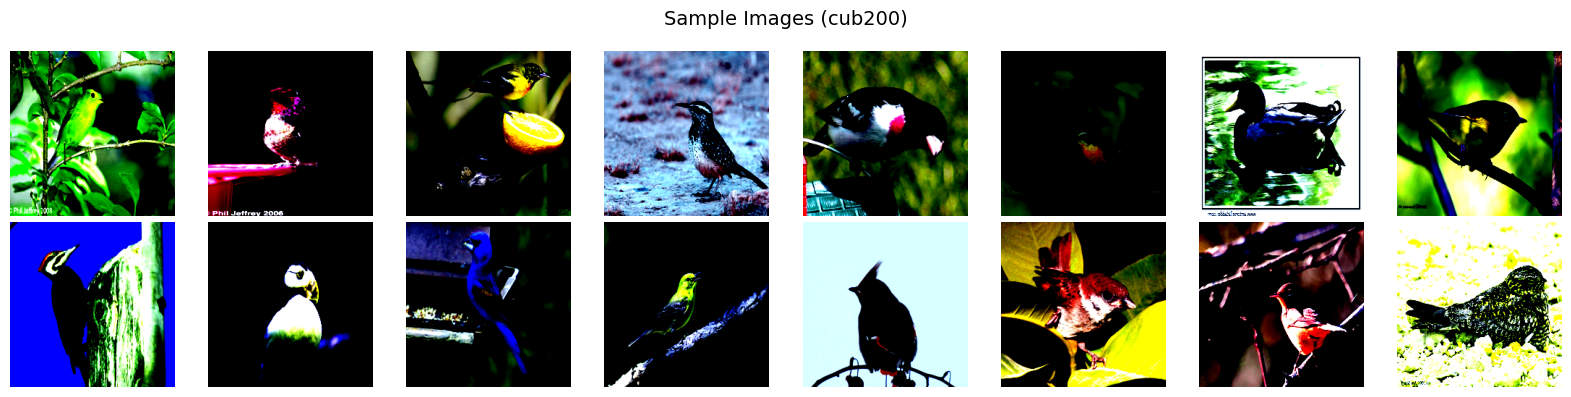

In [3]:
# 데이터 로드
config["dataset"]["root"] = os.path.join(os.getcwd(), "..", "data", "raw")
train_loader, test_loader, num_concepts = get_dataloaders(config)

print(f"Num concepts: {num_concepts}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# 샘플 데이터 확인
images, concept_labels, factor_labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print(f"Concept labels shape: {concept_labels.shape}")
print(f"Factor labels shape: {factor_labels.shape}")

# 샘플 이미지 시각화
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis("off")
plt.suptitle(f"Sample Images ({config['dataset']['name']})", fontsize=14)
plt.tight_layout()
plt.show()

## 3. 모델 생성 및 구조 확인

In [4]:
# Seq-CoRes 모델 생성
mc = config["model"].get("seqcores", {})
sc = config["training"].get("seqcores", {})

model = SeqCoResModel(
    latent_dim=config["model"]["latent_dim"],
    num_codes=mc.get("num_codes", 64),
    code_dim=mc.get("code_dim", 32),
    hidden_dim=mc.get("hidden_dim", 256),
    residual_dim=mc.get("residual_dim", 32),
    max_steps=mc.get("max_steps", 8),
    num_concepts=num_concepts,
    commitment_cost=mc.get("commitment_cost", 0.25),
    ema_decay=mc.get("ema_decay", 0.99),
    image_size=config["dataset"].get("image_size", 64),
    use_decoder=mc.get("use_decoder", True),
    num_gru_layers=mc.get("num_gru_layers", 1),
    num_supervised_slots=mc.get("num_supervised_slots", -1),
).to(device)

# 파라미터 통계
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nComponents:")
print(f"  Backbone:    {sum(p.numel() for p in model.backbone.parameters()):,}")
print(f"  Codebook:    {model.num_codes} × {model.code_dim} = {model.num_codes * model.code_dim:,}")
print(f"  AR Generator:{sum(p.numel() for p in model.ar_generator.parameters()):,}")
print(f"  Residual:    {sum(p.numel() for p in model.residual_terminator.parameters()):,}")
print(f"  Projection:  {sum(p.numel() for p in model.concept_projection.parameters()) + sum(p.numel() for p in model.residual_projection.parameters()):,}")
print(f"  Classifier:  {sum(p.numel() for p in model.classifier.parameters()):,}")
if getattr(model, "use_decoder", False):
    print(f"  Decoder:     {sum(p.numel() for p in model.decoder.parameters()):,}")

Total parameters:     30,967,359
Trainable parameters: 30,963,263

Components:
  Backbone:    23,508,032
  Codebook:    128 × 32 = 4,096
  AR Generator:1,873,728
  Residual:    627,872
  Projection:  18,816
  Classifier:  1,300
  Decoder:     4,924,803


## 4. Forward Pass 테스트 (Sanity Check)

=== Forward Pass Output ===
  z                   : torch.Size([8, 64])
  h_final             : torch.Size([8, 256])
  z_residual          : torch.Size([8, 32])
  selected_codes      : torch.Size([8, 8, 32])
  concept_indices     : torch.Size([8, 8])
  logits              : torch.Size([8, 20])
  vq_loss             : torch.Size([])
  z_continuous        : torch.Size([8, 8, 32])
  concept_emb         : torch.Size([8, 64])
  residual_emb        : torch.Size([8, 64])
  residual_emb_orth   : torch.Size([8, 64])
  slot_concept_preds  : torch.Size([8, 8])
  x_recon             : torch.Size([8, 3, 128, 128])

=== Concept Sequence (코드북 인덱스) ===
  Shape: torch.Size([8, 8])  (B, T)
  Image 0: [73, 30, 30, 30, 30, 30, 30, 30]
  Image 1: [73, 30, 30, 30, 30, 30, 30, 30]
  Image 2: [30, 30, 30, 30, 30, 30, 30, 30]
  Image 3: [72, 30, 30, 30, 30, 30, 30, 30]

=== Residual Norm ===
  Mean: 2.2771
  Std:  0.3162


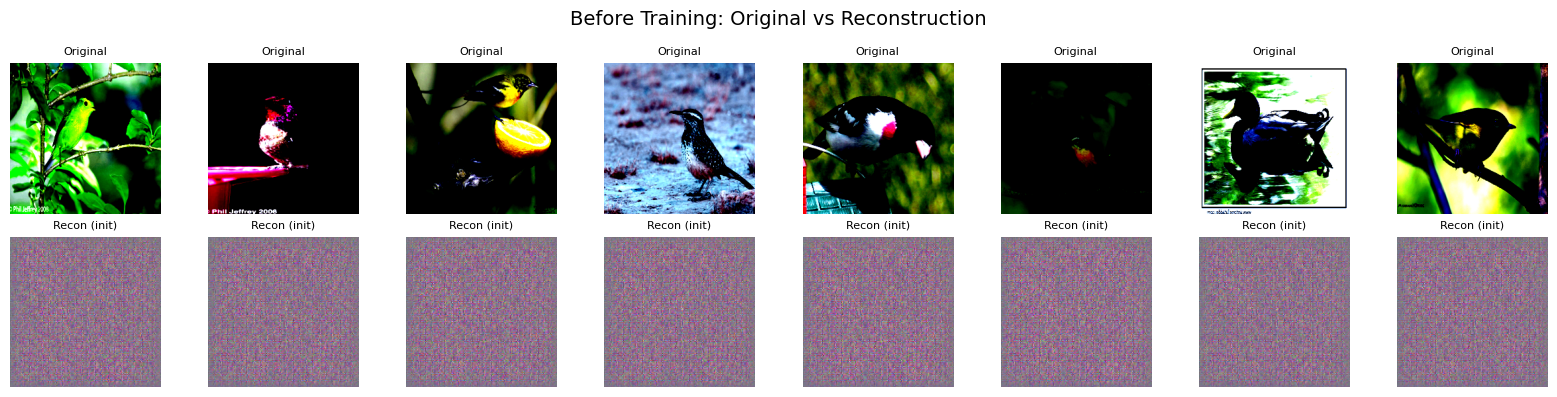

In [5]:
# Forward pass 테스트
model.train()
test_images = images[:8].to(device)
test_labels = concept_labels[:8].to(device)

with torch.no_grad():
    output = model(test_images)

print("=== Forward Pass Output ===")
for key, val in output.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:20s}: {val.shape}")

print(f"\n=== Concept Sequence (코드북 인덱스) ===")
print(f"  Shape: {output['concept_indices'].shape}  (B, T)")
for i in range(min(4, test_images.shape[0])):
    seq = output['concept_indices'][i].cpu().tolist()
    print(f"  Image {i}: {seq}")

print(f"\n=== Residual Norm ===")
res_norms = torch.norm(output['z_residual'], dim=-1).cpu()
print(f"  Mean: {res_norms.mean():.4f}")
print(f"  Std:  {res_norms.std():.4f}")

# 재구성 이미지 확인 (디코더 활성화 시)
if 'x_recon' in output:
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        # 원본
        orig = test_images[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].set_title("Original", fontsize=8)
        axes[0, i].axis("off")
        # 재구성
        recon = output['x_recon'][i].cpu().permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(recon, 0, 1))
        axes[1, i].set_title("Recon (init)", fontsize=8)
        axes[1, i].axis("off")
    plt.suptitle("Before Training: Original vs Reconstruction", fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Two-Phase 학습 실행

### Phase 1: VQ Codebook Warmup
코드북을 의미 있는 시각적 기저(선, 질감, 색상 등)로 초기화합니다.

### Phase 2: Task + Residual Squeezing
분류 학습 + Gumbel-Softmax annealing + 잔차 L2 패널티 점진적 강화

In [6]:
# Loss 생성
criterion = SeqCoResLoss(
    task_weight=sc.get("task_weight", 1.0),
    vq_weight=sc.get("vq_weight", 1.0),
    recon_weight=sc.get("recon_weight", 1.0),
    phase2_recon_weight=sc.get("phase2_recon_weight", 0.1),
    concept_supervision_weight=sc.get("concept_supervision_weight", 1.0),
    residual_penalty_weight=sc.get("residual_penalty_weight", 0.0),
)

# Trainer 생성
trainer = SeqCoResTrainer(model, criterion, config)

print(f"Output dir: {trainer.output_dir}")
print(f"Phase 1: {trainer.phase1_epochs} epochs")
print(f"Phase 2: {trainer.phase2_epochs} epochs")

Output dir: outputs/cores_embedding_default/seqcores
Phase 1: 50 epochs
Phase 2: 80 epochs


In [ ]:
# ⚡ 전체 Two-Phase 학습 실행
# (시간이 오래 걸리므로, 빠른 테스트를 위해 에포크 수를 줄일 수 있습니다)

# 빠른 테스트를 원하면 아래 주석을 해제하세요:
# config["training"]["seqcores"]["phase1_epochs"] = 3
# config["training"]["seqcores"]["phase2_epochs"] = 5

history = trainer.train(train_loader, test_loader)


Seq-CoRes v2 Two-Phase Training
  Device: cuda
  Phase 1 (VQ Warmup):        50 epochs
  Phase 2 (Task + Concepts):  80 epochs
  Total:                      130 epochs
  VQ: STE + EMA  |  Orthogonal Projection: ON


Phase 1: VQ Codebook Warmup (Reconstruction + Concept Align)
  Epochs: 50
  LR: 3e-4
  VQ: STE + EMA



  🔄 Dead Code Revival: 127/128 codes restarted (alive: 1 → 128)


  P1 Epoch   0/50 | Train Loss: 1.5275 | Val Loss: 1.3437 | Time: 19.0s


  🔄 Dead Code Revival: 1/128 codes restarted (alive: 127 → 128)


  P1 Epoch   1/50 | Train Loss: 1.3246 | Val Loss: 1.2439 | Time: 18.8s


...

  P1 Epoch  47/50 | Train Loss: 0.7961 | Val Loss: 1.3282 | Time: 17.9s


  P1 Epoch  48/50 | Train Loss: 0.7980 | Val Loss: 1.3287 | Time: 18.1s


  P1 Epoch  49/50 | Train Loss: 0.7978 | Val Loss: 1.3317 | Time: 18.3s

✅ Phase 1 Complete. Codebook initialized.


Phase 2: Task Learning + Concept Supervision
  Epochs: 80
  LR: 0.0003
  VQ: STE + EMA
  Orthogonal Projection: ON



  P2 Epoch   0/80 | Loss: 1.1004 | ||z_res||: 0.8350 | orth: 0.9833 | Val Loss: 1.8870 | Val Acc: 0.6062 | Time: 18.2s


Phase 2 | Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

## 6. 학습 곡선 시각화

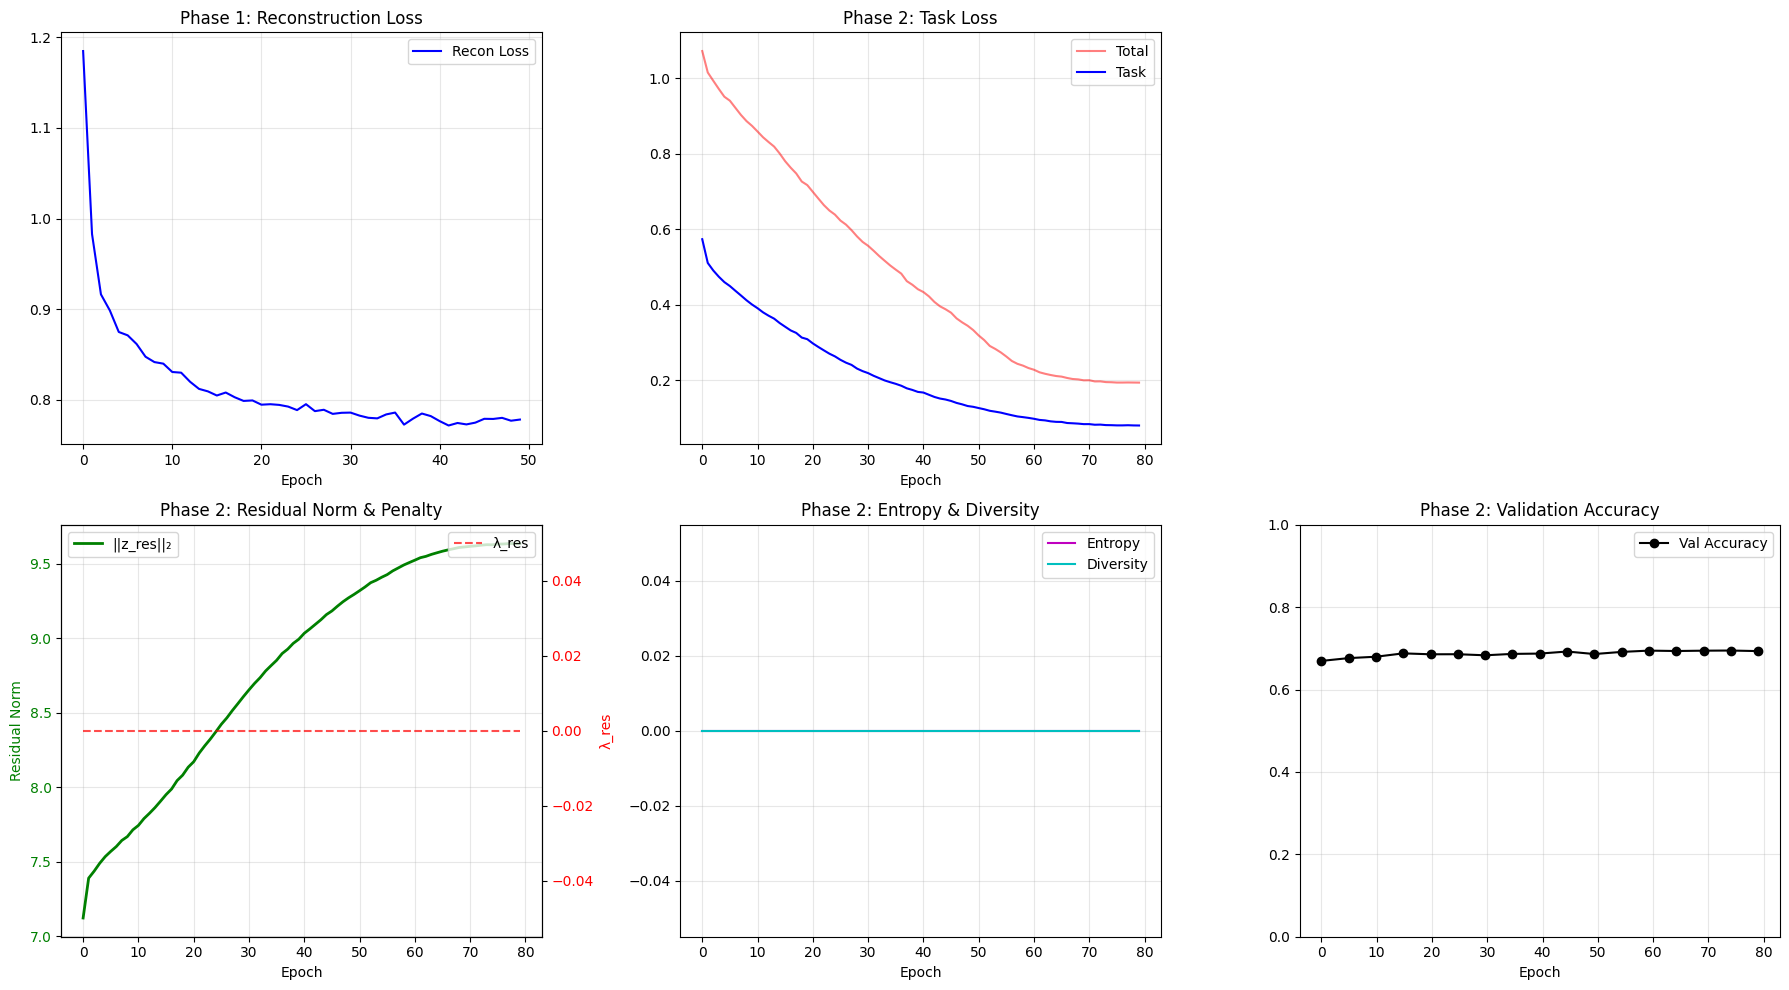

In [ ]:
def plot_training_curves(history):
    """Phase 1 + Phase 2 학습 곡선을 시각화합니다."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- Phase 1: Reconstruction ---
    if "phase1" in history and history["phase1"]["train"]:
        p1_train = history["phase1"]["train"]
        epochs_p1 = range(len(p1_train))

        recon_losses = [d.get("loss_recon", d.get("loss_total", 0)) for d in p1_train]
        axes[0, 0].plot(epochs_p1, recon_losses, "b-", label="Recon Loss")
        axes[0, 0].set_title("Phase 1: Reconstruction Loss")
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # --- Phase 2: Task Loss ---
    if "phase2" in history and history["phase2"]["train"]:
        p2_train = history["phase2"]["train"]
        epochs_p2 = range(len(p2_train))

        task_losses = [d.get("loss_task", 0) for d in p2_train]
        total_losses = [d.get("loss_total", 0) for d in p2_train]
        axes[0, 1].plot(epochs_p2, total_losses, "r-", alpha=0.5, label="Total")
        axes[0, 1].plot(epochs_p2, task_losses, "b-", label="Task")
        axes[0, 1].set_title("Phase 2: Task Loss")
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # --- Residual Norm 추이 (핵심!) ---
        res_norms = [d.get("residual_norm", 0) for d in p2_train]
        res_weights = [d.get("effective_res_weight", 0) for d in p2_train]
        ax_res = axes[1, 0]
        ax_res.plot(epochs_p2, res_norms, "g-", linewidth=2, label="||z_res||₂")
        ax_res.set_ylabel("Residual Norm", color="g")
        ax_res.tick_params(axis="y", labelcolor="g")
        ax_res_twin = ax_res.twinx()
        ax_res_twin.plot(epochs_p2, res_weights, "r--", alpha=0.7, label="λ_res")
        ax_res_twin.set_ylabel("λ_res", color="r")
        ax_res_twin.tick_params(axis="y", labelcolor="r")
        ax_res.set_title("Phase 2: Residual Norm & Penalty")
        ax_res.set_xlabel("Epoch")
        ax_res.legend(loc="upper left")
        ax_res_twin.legend(loc="upper right")
        ax_res.grid(True, alpha=0.3)

        # --- Entropy & Diversity ---
        entropy_losses = [d.get("loss_entropy", 0) for d in p2_train]
        diversity_losses = [d.get("loss_diversity", 0) for d in p2_train]
        axes[1, 1].plot(epochs_p2, entropy_losses, "m-", label="Entropy")
        axes[1, 1].plot(epochs_p2, diversity_losses, "c-", label="Diversity")
        axes[1, 1].set_title("Phase 2: Entropy & Diversity")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        # --- Validation Accuracy ---
        if history["phase2"]["val"]:
            p2_val = history["phase2"]["val"]
            val_epochs = np.linspace(0, len(p2_train)-1, len(p2_val))
            val_accs = [d.get("accuracy", 0) for d in p2_val]
            axes[1, 2].plot(val_epochs, val_accs, "ko-", label="Val Accuracy")
            axes[1, 2].set_title("Phase 2: Validation Accuracy")
            axes[1, 2].set_xlabel("Epoch")
            axes[1, 2].set_ylim([0, 1])
            axes[1, 2].legend()
            axes[1, 2].grid(True, alpha=0.3)

    # 빈 패널 삭제
    axes[0, 2].axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(trainer.output_dir, "training_curves.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

plot_training_curves(history)

## 7. 코드북 분석 (Post-hoc)

학습 완료 후 코드북이 어떤 시각적 패턴을 학습했는지 분석합니다.
1. **코드북 사용 빈도** — 어떤 코드가 자주 사용되는가?
2. **코드북 벡터 유사도** — 코드 간 분화가 잘 되었는가?
3. **코드-인간 개념 정렬** — 자생적 코드가 인간 라벨과 얼마나 일치하는가?

Analyzed 5794 samples, T=8 steps, K=128 codes



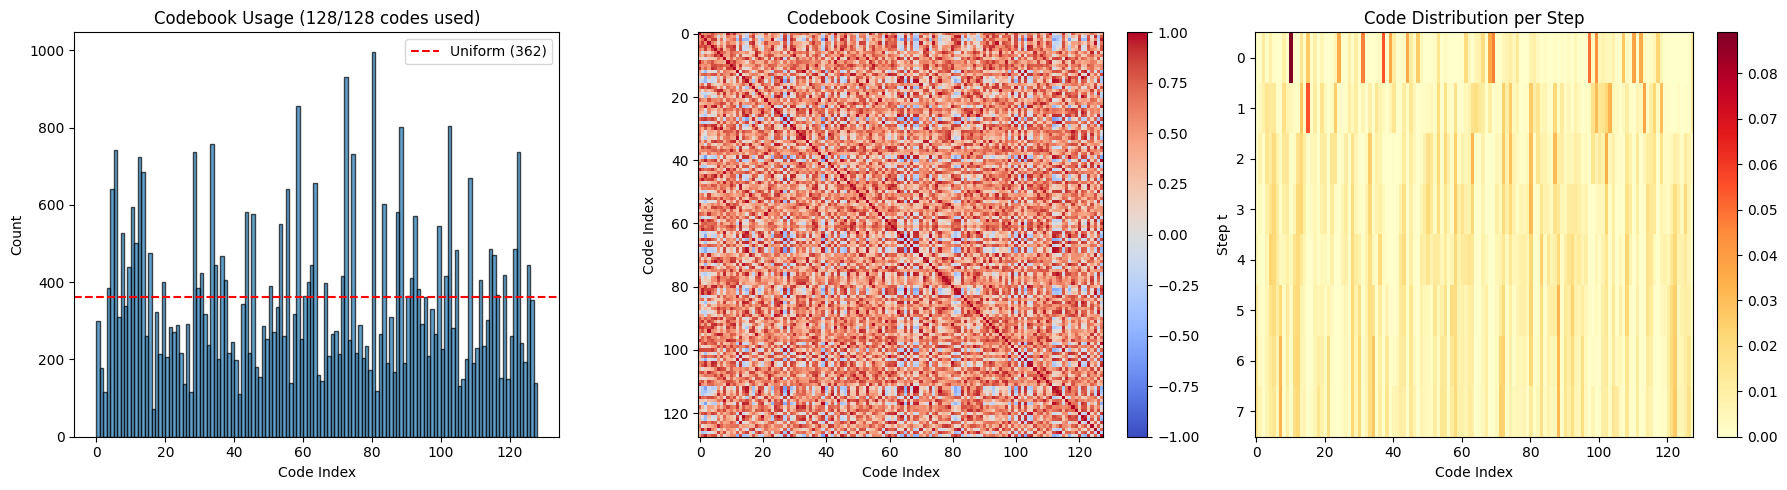


=== Post-hoc Alignment (코드 ↔ 인간 개념 상관관계) ===
  Code   0 (n=  114): concept_4(0.74), concept_1(0.68), concept_7(0.62)
  Code   1 (n=   76): concept_4(0.92), concept_1(0.79), concept_0(0.61)
  Code   2 (n=   73): concept_4(0.86), concept_1(0.79), concept_2(0.64)
  Code   3 (n=  194): concept_4(0.76), concept_1(0.66), concept_0(0.65)
  Code   4 (n=  267): concept_4(0.73), concept_1(0.67), concept_0(0.61)
  Code   5 (n=  310): concept_4(0.74), concept_6(0.70), concept_1(0.70)
  Code   6 (n=  130): concept_6(0.71), concept_2(0.66), concept_0(0.59)
  Code   7 (n=  220): concept_6(0.70), concept_4(0.69), concept_1(0.68)
  Code   8 (n=  210): concept_6(0.72), concept_2(0.69), concept_9(0.48)
  Code   9 (n=  254): concept_4(0.73), concept_0(0.64), concept_1(0.59)
  Code  10 (n=  560): concept_6(0.70), concept_2(0.69), concept_4(0.66)
  Code  11 (n=  178): concept_3(0.67), concept_1(0.66), concept_4(0.64)
  Code  12 (n=  215): concept_3(0.63), concept_12(0.61), concept_15(0.59)
  Code  13 (n=  

In [ ]:
@torch.no_grad()
def analyze_codebook(model, data_loader, device, max_batches=50):
    """코드북 사용 패턴 분석."""
    model.eval()
    all_indices = []
    all_concept_labels = []

    for i, (images, concept_labels, _) in enumerate(data_loader):
        if i >= max_batches:
            break
        images = images.to(device)
        output = model(images)
        all_indices.append(output["concept_indices"].cpu())
        all_concept_labels.append(concept_labels)

    all_indices = torch.cat(all_indices, dim=0)      # [N, T]
    all_concept_labels = torch.cat(all_concept_labels, dim=0)  # [N, C]

    N, T = all_indices.shape
    K = model.num_codes
    print(f"Analyzed {N} samples, T={T} steps, K={K} codes\n")

    # ---- 1. 코드북 사용 빈도 히스토그램 ----
    flat_indices = all_indices.reshape(-1).numpy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(flat_indices, bins=K, range=(0, K), edgecolor="black", alpha=0.7)
    axes[0].set_title("Codebook Usage Frequency")
    axes[0].set_xlabel("Code Index")
    axes[0].set_ylabel("Count")

    used_codes = len(np.unique(flat_indices))
    axes[0].axhline(y=len(flat_indices) / K, color="r", linestyle="--",
                     label=f"Uniform ({len(flat_indices)//K})")
    axes[0].legend()
    axes[0].set_title(f"Codebook Usage ({used_codes}/{K} codes used)")

    # ---- 2. 코드북 벡터 코사인 유사도 행렬 ----
    codebook = model.codebook.codebook.detach().cpu()
    codebook_norm = F.normalize(codebook, dim=-1)
    sim_matrix = codebook_norm @ codebook_norm.t()

    im = axes[1].imshow(sim_matrix.numpy(), cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title("Codebook Cosine Similarity")
    axes[1].set_xlabel("Code Index")
    axes[1].set_ylabel("Code Index")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # ---- 3. 스텝별 코드 분포 (RNN이 순서를 학습했는지?) ----
    step_distributions = []
    for t in range(T):
        counts = np.bincount(all_indices[:, t].numpy(), minlength=K)
        step_distributions.append(counts / counts.sum())

    step_dist_array = np.array(step_distributions)  # [T, K]
    im2 = axes[2].imshow(step_dist_array, aspect="auto", cmap="YlOrRd")
    axes[2].set_title("Code Distribution per Step")
    axes[2].set_xlabel("Code Index")
    axes[2].set_ylabel("Step t")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.savefig(os.path.join(trainer.output_dir, "codebook_analysis.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

    # ---- 4. Post-hoc Alignment: 코드-인간 개념 상관관계 ----
    print("\n=== Post-hoc Alignment (코드 ↔ 인간 개념 상관관계) ===")
    # 각 코드가 활성화된 샘플에서의 인간 개념 평균
    code_concept_corr = torch.zeros(K, all_concept_labels.shape[1])
    code_counts = torch.zeros(K)

    for k in range(K):
        # 어떤 스텝에서든 코드 k가 선택된 샘플 마스크
        mask = (all_indices == k).any(dim=1)  # [N]
        if mask.sum() > 0:
            code_concept_corr[k] = all_concept_labels[mask].float().mean(dim=0)
            code_counts[k] = mask.sum().item()

    # 가장 특징적인 코드-개념 매핑 출력
    for k in range(min(K, 20)):
        if code_counts[k] > 10:
            top_concepts = code_concept_corr[k].topk(3)
            concepts_str = ", ".join(
                [f"concept_{idx.item()}({val:.2f})" for val, idx in
                 zip(top_concepts.values, top_concepts.indices)]
            )
            print(f"  Code {k:3d} (n={int(code_counts[k]):5d}): {concepts_str}")

    return all_indices, all_concept_labels

all_indices, all_labels = analyze_codebook(model, test_loader, device)

## 8. 잔차 분석 — "터미네이터"가 작동했는가?

잔차 벡터의 L2 Norm 분포를 분석하여,
잔차가 실제로 억압되었는지 (거의 0에 가까운지) 확인합니다.

=== Residual Analysis ===
  ||z_res||₂  mean: 2.1034, std: 0.2191
  ||h_T||₂    mean: 8.2975, std: 0.3294
  Ratio (res/h_T)  mean: 0.2539
  → 잔차가 억압됨 ✅


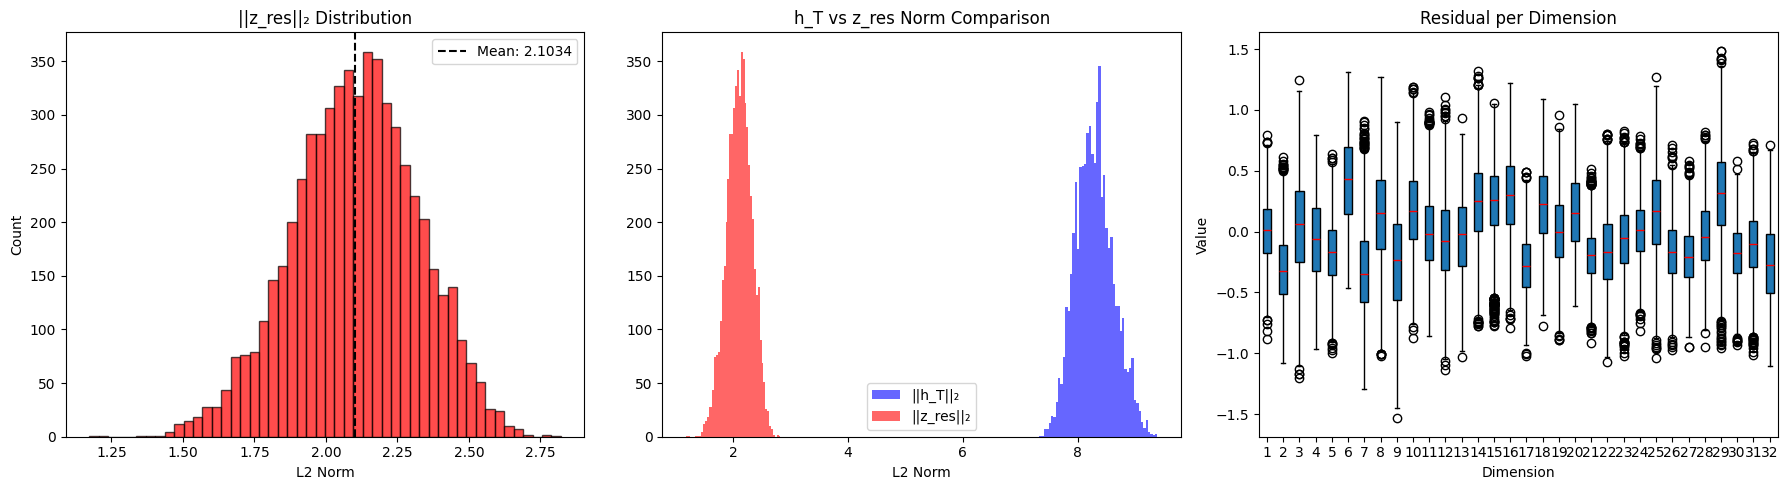

In [ ]:
@torch.no_grad()
def analyze_residual(model, data_loader, device, max_batches=50):
    """잔차 벡터 분석 — 터미네이터 효과 검증."""
    model.eval()
    all_residuals = []
    all_h_finals = []

    for i, (images, _, _) in enumerate(data_loader):
        if i >= max_batches:
            break
        images = images.to(device)
        decomposed = model.get_decomposed_embedding(images)
        all_residuals.append(decomposed["z_residual"].cpu())
        all_h_finals.append(decomposed["h_final"].cpu())

    all_residuals = torch.cat(all_residuals, dim=0)   # [N, res_dim]
    all_h_finals = torch.cat(all_h_finals, dim=0)     # [N, hidden_dim]

    # ---- 잔차 L2 Norm 분포 ----
    res_norms = torch.norm(all_residuals, dim=-1).numpy()  # [N]
    h_norms = torch.norm(all_h_finals, dim=-1).numpy()     # [N]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(res_norms, bins=50, edgecolor="black", alpha=0.7, color="red")
    axes[0].axvline(res_norms.mean(), color="black", linestyle="--",
                     label=f"Mean: {res_norms.mean():.4f}")
    axes[0].set_title("||z_res||₂ Distribution")
    axes[0].set_xlabel("L2 Norm")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # ---- h_T vs z_res Norm 비교 ----
    axes[1].hist(h_norms, bins=50, alpha=0.6, color="blue", label="||h_T||₂")
    axes[1].hist(res_norms, bins=50, alpha=0.6, color="red", label="||z_res||₂")
    axes[1].set_title("h_T vs z_res Norm Comparison")
    axes[1].set_xlabel("L2 Norm")
    axes[1].legend()

    ratio = res_norms / (h_norms + 1e-8)
    print(f"=== Residual Analysis ===")
    print(f"  ||z_res||₂  mean: {res_norms.mean():.4f}, std: {res_norms.std():.4f}")
    print(f"  ||h_T||₂    mean: {h_norms.mean():.4f}, std: {h_norms.std():.4f}")
    print(f"  Ratio (res/h_T)  mean: {ratio.mean():.4f}")
    print(f"  → 잔차가 {'억압됨 ✅' if ratio.mean() < 0.3 else '아직 크다 ⚠️'}")

    # ---- 잔차 차원별 분포 ----
    res_per_dim = all_residuals.numpy()
    axes[2].boxplot(res_per_dim[:, :min(32, res_per_dim.shape[1])],
                     vert=True, patch_artist=True,
                     medianprops=dict(color="red"))
    axes[2].set_title("Residual per Dimension")
    axes[2].set_xlabel("Dimension")
    axes[2].set_ylabel("Value")

    plt.tight_layout()
    plt.savefig(os.path.join(trainer.output_dir, "residual_analysis.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

analyze_residual(model, test_loader, device)

## 9. 개념 시퀀스 궤적 시각화 (Causality)

Seq-CoRes의 핵심 돌파구: "순서"가 만들어내는 자연스러운 인과율.
동일 클래스 내/외 이미지들의 개념 시퀀스를 비교하여 일관된 패턴이 존재하는지 확인합니다.

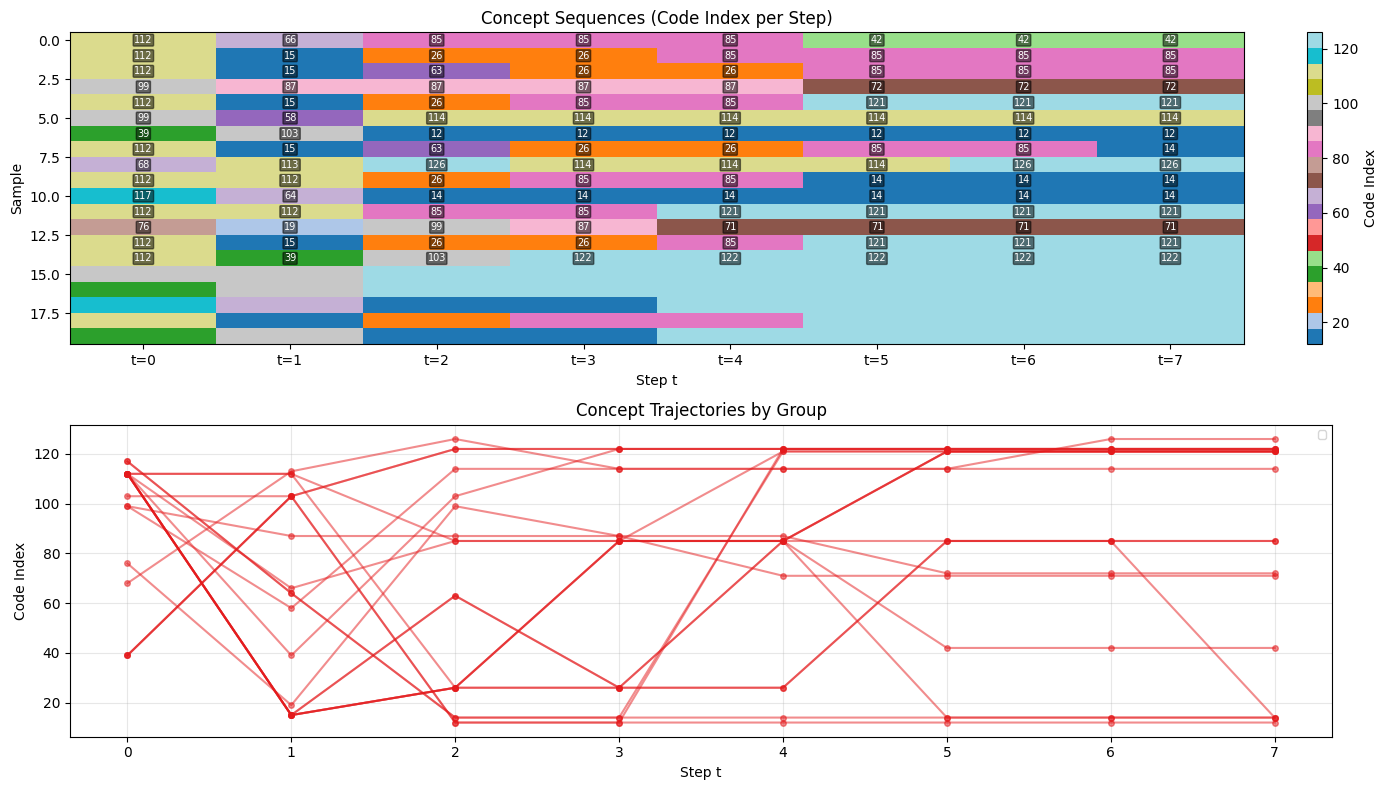


=== Concept Sequence Statistics ===
  Unique sequences: 19 / 20
  Step 0: 7 unique codes used
  Step 1: 10 unique codes used
  Step 2: 11 unique codes used
  Step 3: 7 unique codes used
  Step 4: 9 unique codes used
  Step 5: 9 unique codes used
  Step 6: 10 unique codes used
  Step 7: 10 unique codes used


In [ ]:
@torch.no_grad()
def visualize_concept_sequences(model, data_loader, device, num_samples=20):
    """개념 시퀀스 궤적을 시각화합니다."""
    model.eval()

    images, concept_labels, factor_labels = next(iter(data_loader))
    images = images[:num_samples].to(device)
    concept_labels = concept_labels[:num_samples]
    factor_labels = factor_labels[:num_samples]

    indices, codes, h_final = model.get_concept_sequence(images)  # [N, T]
    indices = indices.cpu().numpy()

    T = indices.shape[1]
    N = indices.shape[0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # ---- 1. 개념 시퀀스 히트맵 ----
    im = axes[0].imshow(indices, aspect="auto", cmap="tab20",
                         interpolation="nearest")
    axes[0].set_title(f"Concept Sequences (Code Index per Step)")
    axes[0].set_xlabel("Step t")
    axes[0].set_ylabel("Sample")
    axes[0].set_xticks(range(T))
    axes[0].set_xticklabels([f"t={t}" for t in range(T)])
    plt.colorbar(im, ax=axes[0], fraction=0.02, label="Code Index")

    # 각 행에 인덱스 표시
    for i in range(min(N, 15)):
        for t in range(T):
            axes[0].text(t, i, str(indices[i, t]), ha="center", va="center",
                         fontsize=7, color="white",
                         bbox=dict(boxstyle="round,pad=0.1", facecolor="black",
                                   alpha=0.5))

    # ---- 2. 동일 팩터 라벨 그룹의 시퀀스 일관성 ----
    # factor_labels의 첫 번째 팩터로 그룹핑
    if factor_labels.dim() > 1:
        group_labels = factor_labels[:, 0].numpy()
    else:
        group_labels = factor_labels.numpy()

    unique_groups = np.unique(group_labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_groups)))

    for g_idx, g in enumerate(unique_groups[:8]):  # 최대 8그룹
        mask = group_labels == g
        if mask.sum() > 0:
            group_seqs = indices[mask]
            for seq in group_seqs:
                axes[1].plot(range(T), seq, "o-", color=colors[g_idx],
                             alpha=0.5, markersize=4, label=f"Group {int(g)}"
                             if seq is group_seqs[0] else "")

    axes[1].set_title("Concept Trajectories by Group")
    axes[1].set_xlabel("Step t")
    axes[1].set_ylabel("Code Index")
    axes[1].set_xticks(range(T))
    # 중복 라벨 제거
    handles, labels = axes[1].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[1].legend(by_label.values(), by_label.keys(),
                   loc="upper right", fontsize=8, ncol=2)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(trainer.output_dir, "concept_sequences.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

    # 시퀀스 요약 통계
    print(f"\n=== Concept Sequence Statistics ===")
    print(f"  Unique sequences: {len(np.unique(indices, axis=0))} / {N}")
    for t in range(T):
        unique_at_t = len(np.unique(indices[:, t]))
        print(f"  Step {t}: {unique_at_t} unique codes used")

visualize_concept_sequences(model, test_loader, device)

## 10. 노이즈 안정성 테스트 (Discrete Snap)

코드북의 이산성이 노이즈에 대한 안정성을 제공하는지 검증합니다.
입력에 가우시안 노이즈를 추가해도 동일한 코드 인덱스로 "스냅"되는지 확인.

=== Noise Stability Test ===
  σ=0.01 | Code Agreement: 0.1934 | Embedding Cos Sim: 0.6230
  σ=0.05 | Code Agreement: 0.1602 | Embedding Cos Sim: 0.6165
  σ=0.10 | Code Agreement: 0.1270 | Embedding Cos Sim: 0.6007
  σ=0.20 | Code Agreement: 0.1348 | Embedding Cos Sim: 0.5800
  σ=0.50 | Code Agreement: 0.0449 | Embedding Cos Sim: 0.3935


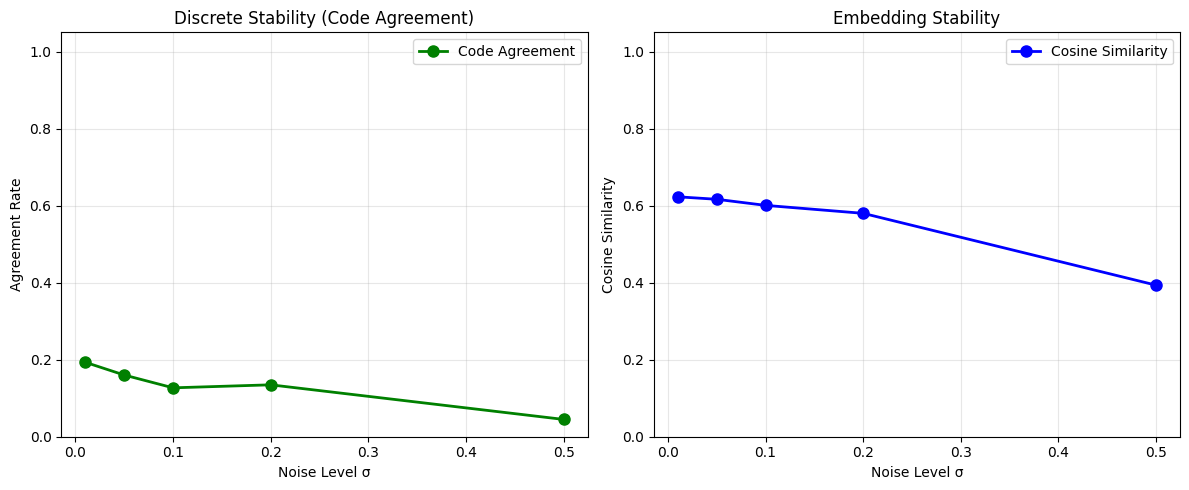

In [ ]:
@torch.no_grad()
def test_noise_stability(model, data_loader, device,
                         noise_levels=[0.01, 0.05, 0.1, 0.2, 0.5]):
    """노이즈 안정성 테스트 — 이산 코드의 "스냅" 효과."""
    model.eval()

    images, _, _ = next(iter(data_loader))
    images = images[:64].to(device)

    # 원본 코드 시퀀스
    orig_indices, _, _ = model.get_concept_sequence(images)
    orig_indices = orig_indices.cpu()

    # 원본 임베딩
    orig_emb = model.get_embedding(images).cpu()

    results = {"noise_level": [], "code_agreement": [], "embedding_cosine_sim": []}

    for sigma in noise_levels:
        # 노이즈 추가
        noisy = torch.clamp(images + sigma * torch.randn_like(images), 0, 1)
        noisy_indices, _, _ = model.get_concept_sequence(noisy)
        noisy_indices = noisy_indices.cpu()
        noisy_emb = model.get_embedding(noisy).cpu()

        # 코드 일치율 (이산 안정성)
        agreement = (orig_indices == noisy_indices).float().mean().item()

        # 임베딩 코사인 유사도 (연속 안정성)
        cos_sim = F.cosine_similarity(orig_emb, noisy_emb, dim=-1).mean().item()

        results["noise_level"].append(sigma)
        results["code_agreement"].append(agreement)
        results["embedding_cosine_sim"].append(cos_sim)

        print(f"  σ={sigma:.2f} | Code Agreement: {agreement:.4f} | "
              f"Embedding Cos Sim: {cos_sim:.4f}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(results["noise_level"], results["code_agreement"],
                 "go-", linewidth=2, markersize=8, label="Code Agreement")
    axes[0].set_title("Discrete Stability (Code Agreement)")
    axes[0].set_xlabel("Noise Level σ")
    axes[0].set_ylabel("Agreement Rate")
    axes[0].set_ylim([0, 1.05])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(results["noise_level"], results["embedding_cosine_sim"],
                 "bo-", linewidth=2, markersize=8, label="Cosine Similarity")
    axes[1].set_title("Embedding Stability")
    axes[1].set_xlabel("Noise Level σ")
    axes[1].set_ylabel("Cosine Similarity")
    axes[1].set_ylim([0, 1.05])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(trainer.output_dir, "noise_stability.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

    return results

print("=== Noise Stability Test ===")
stability_results = test_noise_stability(model, test_loader, device)

## 11. 모델 저장 및 요약

In [ ]:
# 최종 요약
print("=" * 60)
print("Seq-CoRes Training Summary")
print("=" * 60)
print(f"  Dataset:        {config['dataset']['name']}")
print(f"  Codebook K:     {model.num_codes}")
print(f"  Max Steps T:    {model.max_steps}")
print(f"  Latent Dim D:   {model.latent_dim}")
print(f"  Total Params:   {total_params:,}")
print(f"  Output Dir:     {trainer.output_dir}")

# 최종 Gumbel tau
print(f"  Final τ:        {model.get_gumbel_tau():.4f}")

# 잔차 상태
model.eval()
with torch.no_grad():
    sample_imgs, _, _ = next(iter(test_loader))
    sample_imgs = sample_imgs[:32].to(device)
    decomposed = model.get_decomposed_embedding(sample_imgs)
    final_res_norm = decomposed["residual_norm"].mean().item()
    print(f"  Final ||z_res||: {final_res_norm:.4f}")

# 코드북 사용률
util = model.get_codebook_utilization()
print(f"  Codebook:       {util['num_codes']} codes × {util['code_dim']} dims")
print("=" * 60)
print(f"\n📁 All outputs saved to: {trainer.output_dir}")
print("🎉 Experiment complete!")

Seq-CoRes Training Summary
  Dataset:        cub200
  Codebook K:     128
  Max Steps T:    8
  Latent Dim D:   64
  Total Params:   16,863,039
  Output Dir:     outputs/cores_embedding_default/seqcores
  Final τ:        0.0000
  Final ||z_res||: 9.7173
  Codebook:       128 codes × 32 dims

📁 All outputs saved to: outputs/cores_embedding_default/seqcores
🎉 Experiment complete!


In [ ]:
import json
from datetime import datetime

def save_experiment_results(model, trainer, config, history,
                            stability_results, train_loader, test_loader,
                            device):
    """모든 실험 결과를 텍스트 리포트와 JSON으로 저장합니다."""

    output_dir = trainer.output_dir
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # ================================================================
    # 1. 수치 결과 수집
    # ================================================================
    model.eval()

    # --- 최종 잔차 통계 ---
    all_res_norms = []
    all_h_norms = []
    with torch.no_grad():
        for i, (imgs, _, _) in enumerate(test_loader):
            if i >= 50:
                break
            imgs = imgs.to(device)
            dec = model.get_decomposed_embedding(imgs)
            all_res_norms.append(torch.norm(dec["z_residual"], dim=-1).cpu())
            all_h_norms.append(torch.norm(dec["h_final"], dim=-1).cpu())

    all_res_norms = torch.cat(all_res_norms)
    all_h_norms = torch.cat(all_h_norms)
    res_ratio = (all_res_norms / (all_h_norms + 1e-8)).mean().item()

    # --- 코드북 사용률 ---
    all_indices = []
    with torch.no_grad():
        for i, (imgs, _, _) in enumerate(test_loader):
            if i >= 50:
                break
            imgs = imgs.to(device)
            out = model(imgs)
            all_indices.append(out["concept_indices"].cpu())
    all_indices_cat = torch.cat(all_indices, dim=0)
    flat_idx = all_indices_cat.reshape(-1).numpy()
    used_codes = len(np.unique(flat_idx))
    total_codes = model.num_codes

    # --- Phase별 최종 메트릭 ---
    p1_final = {}
    if "phase1" in history and history["phase1"]["train"]:
        p1_final = history["phase1"]["train"][-1]

    p2_final_train = {}
    p2_final_val = {}
    if "phase2" in history and history["phase2"]["train"]:
        p2_final_train = history["phase2"]["train"][-1]
    if "phase2" in history and history["phase2"]["val"]:
        p2_final_val = history["phase2"]["val"][-1]

    # --- 파라미터 수 ---
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                           if p.requires_grad)

    # ================================================================
    # 2. JSON 저장 (프로그래밍 방식 재사용)
    # ================================================================
    results_dict = {
        "meta": {
            "timestamp": timestamp,
            "dataset": config["dataset"]["name"],
            "device": config["experiment"].get("device", "unknown"),
            "seed": config["experiment"].get("seed", -1),
        },
        "model": {
            "name": "SeqCoRes",
            "latent_dim": model.latent_dim,
            "num_codes": model.num_codes,
            "code_dim": model.code_dim,
            "hidden_dim": model.hidden_dim,
            "residual_dim": model.residual_dim,
            "max_steps": model.max_steps,
            "total_params": total_params,
            "trainable_params": trainable_params,
            "final_gumbel_tau": model.get_gumbel_tau(),
        },
        "training": {
            "phase1_epochs": trainer.phase1_epochs,
            "phase2_epochs": trainer.phase2_epochs,
            "phase1_final_metrics": {
                k: float(v) if isinstance(v, (int, float)) else v
                for k, v in p1_final.items()
            },
            "phase2_final_train_metrics": {
                k: float(v) if isinstance(v, (int, float)) else v
                for k, v in p2_final_train.items()
            },
            "phase2_final_val_metrics": {
                k: float(v) if isinstance(v, (int, float)) else v
                for k, v in p2_final_val.items()
            },
        },
        "codebook_analysis": {
            "used_codes": int(used_codes),
            "total_codes": int(total_codes),
            "utilization_rate": round(used_codes / total_codes, 4),
        },
        "residual_analysis": {
            "z_res_l2_mean": round(all_res_norms.mean().item(), 6),
            "z_res_l2_std": round(all_res_norms.std().item(), 6),
            "h_T_l2_mean": round(all_h_norms.mean().item(), 6),
            "h_T_l2_std": round(all_h_norms.std().item(), 6),
            "ratio_res_over_hT": round(res_ratio, 6),
            "residual_suppressed": res_ratio < 0.3,
        },
        "noise_stability": stability_results if stability_results else {},
        "training_history": {
            "phase1_loss_curve": [
                d.get("loss_total", d.get("loss_recon", 0))
                for d in history.get("phase1", {}).get("train", [])
            ],
            "phase2_task_loss_curve": [
                d.get("loss_task", 0)
                for d in history.get("phase2", {}).get("train", [])
            ],
            "phase2_residual_norm_curve": [
                d.get("residual_norm", 0)
                for d in history.get("phase2", {}).get("train", [])
            ],
            "phase2_val_accuracy_curve": [
                d.get("accuracy", 0)
                for d in history.get("phase2", {}).get("val", [])
            ],
        },
    }

    json_path = os.path.join(output_dir, "experiment_results.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(results_dict, f, indent=2, ensure_ascii=False)
    print(f"✅ JSON saved: {json_path}")

    # ================================================================
    # 3. 텍스트 리포트 저장 (사람이 읽기 쉬운 형태)
    # ================================================================
    report_lines = []
    sep = "=" * 70

    report_lines.append(sep)
    report_lines.append("  Seq-CoRes Experiment Report")
    report_lines.append(sep)
    report_lines.append(f"  Timestamp:  {timestamp}")
    report_lines.append(f"  Dataset:    {config['dataset']['name']}")
    report_lines.append(f"  Device:     {config['experiment'].get('device')}")
    report_lines.append(f"  Seed:       {config['experiment'].get('seed')}")
    report_lines.append("")

    # --- Model ---
    report_lines.append("-" * 70)
    report_lines.append("  MODEL ARCHITECTURE")
    report_lines.append("-" * 70)
    report_lines.append(f"  Latent Dim D:      {model.latent_dim}")
    report_lines.append(f"  Codebook K:        {model.num_codes}")
    report_lines.append(f"  Code Dim:          {model.code_dim}")
    report_lines.append(f"  Hidden Dim (GRU):  {model.hidden_dim}")
    report_lines.append(f"  Residual Dim:      {model.residual_dim}")
    report_lines.append(f"  Max Steps T:       {model.max_steps}")
    report_lines.append(f"  Total Params:      {total_params:,}")
    report_lines.append(f"  Trainable Params:  {trainable_params:,}")
    report_lines.append(f"  Final Gumbel τ:    {model.get_gumbel_tau():.6f}")
    report_lines.append("")

    # --- Training ---
    report_lines.append("-" * 70)
    report_lines.append("  TRAINING SUMMARY")
    report_lines.append("-" * 70)
    report_lines.append(f"  Phase 1 Epochs:    {trainer.phase1_epochs}")
    report_lines.append(f"  Phase 2 Epochs:    {trainer.phase2_epochs}")
    report_lines.append("")

    if p1_final:
        report_lines.append("  [Phase 1 Final Metrics]")
        for k, v in p1_final.items():
            if isinstance(v, float):
                report_lines.append(f"    {k:30s}: {v:.6f}")
            else:
                report_lines.append(f"    {k:30s}: {v}")
        report_lines.append("")

    if p2_final_train:
        report_lines.append("  [Phase 2 Final Train Metrics]")
        for k, v in p2_final_train.items():
            if isinstance(v, float):
                report_lines.append(f"    {k:30s}: {v:.6f}")
            else:
                report_lines.append(f"    {k:30s}: {v}")
        report_lines.append("")

    if p2_final_val:
        report_lines.append("  [Phase 2 Final Validation Metrics]")
        for k, v in p2_final_val.items():
            if isinstance(v, float):
                report_lines.append(f"    {k:30s}: {v:.6f}")
            else:
                report_lines.append(f"    {k:30s}: {v}")
        report_lines.append("")

    # --- Codebook ---
    report_lines.append("-" * 70)
    report_lines.append("  CODEBOOK ANALYSIS")
    report_lines.append("-" * 70)
    report_lines.append(f"  Used Codes:        {used_codes} / {total_codes}")
    report_lines.append(f"  Utilization:       {used_codes/total_codes*100:.1f}%")
    report_lines.append("")

    # --- Residual ---
    report_lines.append("-" * 70)
    report_lines.append("  RESIDUAL ANALYSIS (Terminator Effect)")
    report_lines.append("-" * 70)
    report_lines.append(
        f"  ||z_res||₂ mean:   {all_res_norms.mean().item():.6f}  "
        f"(std: {all_res_norms.std().item():.6f})")
    report_lines.append(
        f"  ||h_T||₂   mean:   {all_h_norms.mean().item():.6f}  "
        f"(std: {all_h_norms.std().item():.6f})")
    report_lines.append(f"  Ratio (res/h_T):   {res_ratio:.6f}")
    verdict = "✅ 억압 성공" if res_ratio < 0.3 else "⚠️  아직 큼"
    report_lines.append(f"  Verdict:           {verdict}")
    report_lines.append("")

    # --- Noise Stability ---
    report_lines.append("-" * 70)
    report_lines.append("  NOISE STABILITY TEST (Discrete Snap)")
    report_lines.append("-" * 70)
    if stability_results and stability_results.get("noise_level"):
        report_lines.append(
            f"  {'σ':>8s}  {'Code Agree':>12s}  {'Cos Sim':>10s}")
        report_lines.append(f"  {'─'*8}  {'─'*12}  {'─'*10}")
        for sigma, agree, cos in zip(
            stability_results["noise_level"],
            stability_results["code_agreement"],
            stability_results["embedding_cosine_sim"],
        ):
            report_lines.append(f"  {sigma:8.3f}  {agree:12.4f}  {cos:10.4f}")
    else:
        report_lines.append("  (not executed)")
    report_lines.append("")

    # --- Config Dump ---
    report_lines.append("-" * 70)
    report_lines.append("  FULL CONFIGURATION")
    report_lines.append("-" * 70)
    for section, values in config.items():
        report_lines.append(f"  [{section}]")
        if isinstance(values, dict):
            for k, v in values.items():
                if isinstance(v, dict):
                    report_lines.append(f"    [{k}]")
                    for kk, vv in v.items():
                        report_lines.append(f"      {kk:28s}: {vv}")
                else:
                    report_lines.append(f"    {k:30s}: {v}")
        report_lines.append("")

    report_lines.append(sep)
    report_lines.append("  END OF REPORT")
    report_lines.append(sep)

    report_text = "\n".join(report_lines)

    txt_path = os.path.join(output_dir, "experiment_report.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(report_text)
    print(f"✅ Report saved: {txt_path}")

    # ================================================================
    # 4. 학습 곡선 CSV 저장 (스프레드시트 분석용)
    # ================================================================
    import csv

    # Phase 1 CSV
    if history.get("phase1", {}).get("train"):
        csv_p1 = os.path.join(output_dir, "phase1_history.csv")
        p1_data = history["phase1"]["train"]
        if p1_data:
            keys = list(p1_data[0].keys())
            with open(csv_p1, "w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=["epoch"] + keys)
                writer.writeheader()
                for ep, row in enumerate(p1_data):
                    writer.writerow({"epoch": ep, **row})
            print(f"✅ Phase 1 CSV saved: {csv_p1}")

    # Phase 2 Train CSV
    if history.get("phase2", {}).get("train"):
        csv_p2 = os.path.join(output_dir, "phase2_train_history.csv")
        p2_data = history["phase2"]["train"]
        if p2_data:
            keys = list(p2_data[0].keys())
            with open(csv_p2, "w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=["epoch"] + keys)
                writer.writeheader()
                for ep, row in enumerate(p2_data):
                    writer.writerow({"epoch": ep, **row})
            print(f"✅ Phase 2 Train CSV saved: {csv_p2}")

    # Phase 2 Val CSV
    if history.get("phase2", {}).get("val"):
        csv_p2v = os.path.join(output_dir, "phase2_val_history.csv")
        p2v_data = history["phase2"]["val"]
        if p2v_data:
            keys = list(p2v_data[0].keys())
            with open(csv_p2v, "w", newline="", encoding="utf-8") as f:
                writer = csv.DictWriter(f, fieldnames=["eval_idx"] + keys)
                writer.writeheader()
                for idx, row in enumerate(p2v_data):
                    writer.writerow({"eval_idx": idx, **row})
            print(f"✅ Phase 2 Val CSV saved: {csv_p2v}")

    # 콘솔에도 리포트 출력
    print("\n" + report_text)

    return results_dict, report_text


# ---- 실행 ----
results_dict, report_text = save_experiment_results(
    model=model,
    trainer=trainer,
    config=config,
    history=history,
    stability_results=stability_results,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
)

✅ JSON saved: outputs/cores_embedding_default/seqcores/experiment_results.json
✅ Report saved: outputs/cores_embedding_default/seqcores/experiment_report.txt
✅ Phase 1 CSV saved: outputs/cores_embedding_default/seqcores/phase1_history.csv
✅ Phase 2 Train CSV saved: outputs/cores_embedding_default/seqcores/phase2_train_history.csv
✅ Phase 2 Val CSV saved: outputs/cores_embedding_default/seqcores/phase2_val_history.csv

  Seq-CoRes Experiment Report
  Timestamp:  2026-03-03 16:15:13
  Dataset:    cub200
  Device:     cuda
  Seed:       42

----------------------------------------------------------------------
  MODEL ARCHITECTURE
----------------------------------------------------------------------
  Latent Dim D:      64
  Codebook K:        128
  Code Dim:          32
  Hidden Dim (GRU):  256
  Residual Dim:      32
  Max Steps T:       8
  Total Params:      16,863,039
  Trainable Params:  16,858,943
  Final Gumbel τ:    0.000000

-----------------------------------------------------